# USS 过山车等待时间分析

**问题**：什么时候去排队最短？（几点 / 星期几）天气有没有影响？

- `data/waits.csv` — 定时 routine 每小时（约 :24）抓取的 Battlestar Galactica (HUMAN/CYLON) 等待时间
- `data/weather.csv` — Open-Meteo 拉取的 USS 圣淘沙坐标 (1.254°N, 103.824°E) **15 分钟粒度**天气

数据由 `fetch_data.py` 拉取；分析逻辑在 `analysis_lib.py`，均可复用。

> ⚠️ **数据量小**：仅约 8 天、仅营业时段（10:00–19:00）。结论**初步**，会随数据累积变化。

In [1]:
import sys, os
sys.path.insert(0, r'C:\Users\huimin.li2\uss-analysis')
os.chdir(r'C:\Users\huimin.li2\uss-analysis')
import matplotlib.pyplot as plt
import matplotlib
import analysis_lib as A
matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
waits = A.load_waits(); weather = A.load_weather(); df = A.merge_waits_weather(waits, weather)
print(f'清洗后等待记录 {len(waits)} 条，覆盖 {waits["date"].nunique()} 天；'
      f'天气合并成功率 {df["temperature_2m"].notna().mean():.0%}，'
      f'天气对齐平均差 {(df["ts"]-df["wtime"]).abs().dt.total_seconds().mean()/60:.1f} 分钟')
df.head()

清洗后等待记录 129 条，覆盖 9 天；天气合并成功率 100%，天气对齐平均差 5.9 分钟


,fetched_at_sgt,ride,status,wait_time,last_updated,ts,last_updated_sgt,stale_min,date,hour,...,temperature_2m,apparent_temperature,relative_humidity_2m,precipitation,rain,weather_code,cloud_cover,wind_speed_10m,weather_group,is_rain
0,2026-07-16T17:25:28+08:00,HUMAN,OPERATING,50,2026-07-16T09:18:00.442Z,2026-07-16 17:25:28,2026-07-16 17:18:00.442,7.459300,2026-07-16,17,...,31.3,34.5,58,0.0,0.0,3,97,12.4,阴,False
1,2026-07-16T17:25:28+08:00,CYLON,OPERATING,60,2026-07-16T08:42:29.622Z,2026-07-16 17:25:28,2026-07-16 16:42:29.622,42.972967,2026-07-16,17,...,31.3,34.5,58,0.0,0.0,3,97,12.4,阴,False
2,2026-07-16T18:23:58+08:00,HUMAN,OPERATING,80,2026-07-16T10:11:03.334Z,2026-07-16 18:23:58,2026-07-16 18:11:03.334,12.911100,2026-07-16,18,...,30.5,33.9,63,0.0,0.0,2,71,12.3,多云,False
3,2026-07-16T18:23:58+08:00,CYLON,OPERATING,50,2026-07-16T10:15:13.056Z,2026-07-16 18:23:58,2026-07-16 18:15:13.056,8.749067,2026-07-16,18,...,30.5,33.9,63,0.0,0.0,2,71,12.3,多云,False
4,2026-07-16T19:23:54+08:00,HUMAN,OPERATING,40,2026-07-16T11:09:20.403Z,2026-07-16 19:23:54,2026-07-16 19:09:20.403,14.559950,2026-07-16,19,...,29.7,33.6,69,0.0,0.0,2,74,12.1,多云,False


## 0. 数据清洗（丢弃不合理数据）

**剔除 `wait_time == 0` 的记录**：这些 0 值散布在营业各时段（不只是闭园前），实为过山车临时停运 / 接口故障产生的**假零排队**，会把某些小时的均值错误拉低。不做“同一测量被多小时重复抓取”的去重——稳定不变的排队值在每个时钟小时都是当时的真实当前值。

In [2]:
raw = A.load_waits(drop_zero=False)
n_zero = int((raw['wait_time'] == 0).sum())
print(f'原始有效记录 {len(raw)} 条，其中 wait_time==0 的假零 {n_zero} 条已剔除，剩 {len(waits)} 条')
print('\n被剔除的 0 值出现在这些小时（可见并非只在闭园）：')
print(raw[raw['wait_time']==0]['hour'].value_counts().sort_index().to_string())

原始有效记录 150 条，其中 wait_time==0 的假零 21 条已剔除，剩 129 条

被剔除的 0 值出现在这些小时（可见并非只在闭园）：
hour
10    1
12    2
13    4
14    2
15    1
17    2
18    2
19    7


## 1. 数据完整度
只有营业时段被抓取，共约 8 天，首尾两天不完整。**每个“星期几”大约只有 1 天数据**，所以按星期的比较不可靠；按“小时”的规律相对可信。

In [3]:
cov = waits.groupby('date').agg(最早=('hour','min'), 最晚=('hour','max'),
                                小时数=('hour','nunique'), 记录数=('wait_time','count'))
print(cov.to_string())

            最早  最晚  小时数  记录数
date                        
2026-07-16  17  19    3    6
2026-07-17  10  18    7   14
2026-07-18  10  16    7   14
2026-07-19  10  18    9   18
2026-07-20  10  19   10   19
2026-07-21  10  19    9   18
2026-07-22  10  19    8   14
2026-07-23  10  19   10   20
2026-07-24  10  12    3    6


## 2. 一天中什么时候等待最短？

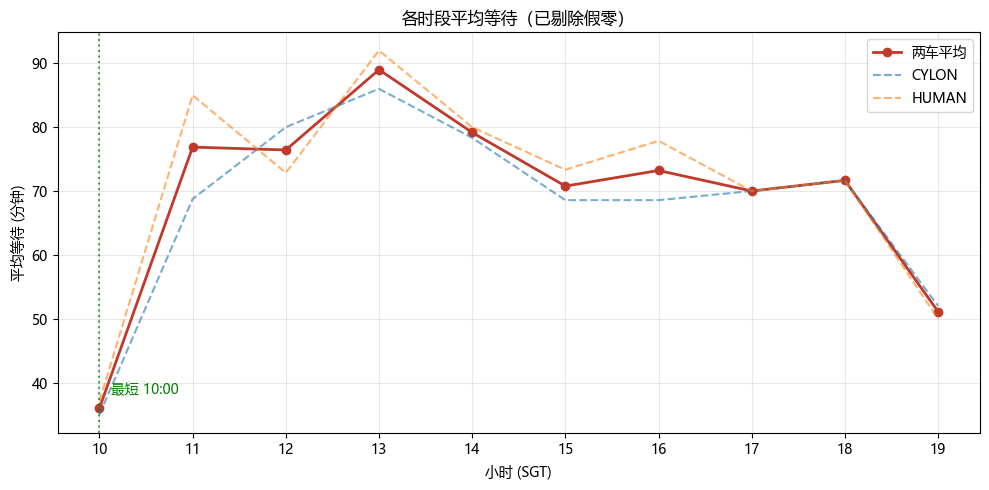

 hour  mean  median  count
   10  36.0    40.0     15
   11  76.9    80.0     16
   12  76.4    75.0     14
   13  89.0    90.0     10
   14  79.2    80.0     12
   15  70.8    70.0     13
   16  73.2    70.0     14
   17  70.0    70.0     14
   18  71.7    80.0     12
   19  51.1    50.0      9


In [4]:
hourly = A.by_hour(df); by_ride = A.by_hour_ride(df)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hourly['hour'], hourly['mean'], 'o-', lw=2, color='#c0392b', label='两车平均')
for r in by_ride.columns: ax.plot(by_ride.index, by_ride[r], '--', alpha=0.6, label=r)
best = int(hourly.loc[hourly['mean'].idxmin(), 'hour'])
ax.axvline(best, color='green', ls=':', alpha=0.7)
ax.annotate(f'最短 {best}:00', (best, hourly['mean'].min()), textcoords='offset points', xytext=(8,10), color='green')
ax.set_xlabel('小时 (SGT)'); ax.set_ylabel('平均等待 (分钟)'); ax.set_title('各时段平均等待（已剔除假零）')
ax.set_xticks(hourly['hour']); ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(hourly.round(1).to_string(index=False))

**读图**：**开园的 10:00 最短（约 35 分）**，随后迅速攀升，**13:00 前后见顶（约 89 分）**，**11:00–18:00 全程高位（70–89 分）**。19:00 有回落但仅 7 个样本、不够可靠。“早去”是唯一清晰稳健的规律。两车走势一致。

## 3. 一周中哪天去比较好？
> ⚠️ **不可靠**：每个星期几目前只有约 1 天数据，差异基本是单日噪声。以下仅作参考。

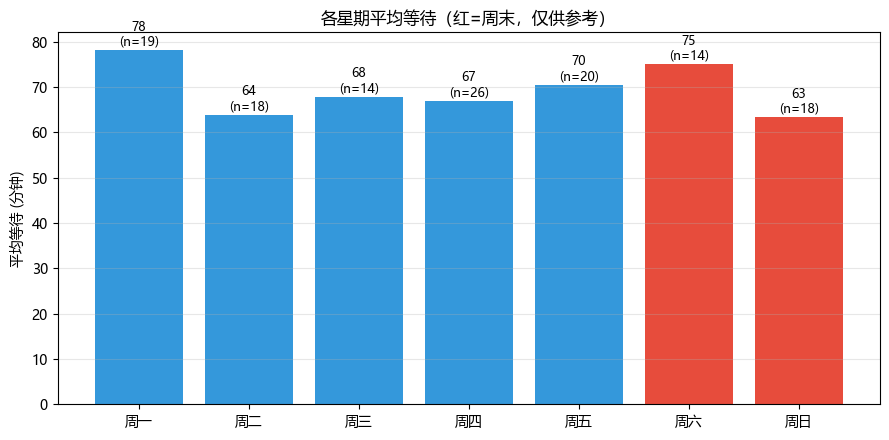

星期  mean  count
周一  78.2     19
周二  63.9     18
周三  67.9     14
周四  66.9     26
周五  70.5     20
周六  75.0     14
周日  63.3     18

工作日 69.4 分 vs 周末 68.4 分


In [5]:
dow = A.by_dow(df)
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ['#e74c3c' if n in ('周六','周日') else '#3498db' for n in dow['星期']]
ax.bar(dow['星期'], dow['mean'], color=colors)
for i,(m,n) in enumerate(zip(dow['mean'], dow['count'])): ax.text(i, m+1, f'{m:.0f}\n(n={n})', ha='center', fontsize=9)
ax.set_ylabel('平均等待 (分钟)'); ax.set_title('各星期平均等待（红=周末，仅供参考）'); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()
print(dow[['星期','mean','count']].round(1).to_string(index=False))
print(f"\n工作日 {df[~df['is_weekend']]['wait_time'].mean():.1f} 分 vs 周末 {df[df['is_weekend']]['wait_time'].mean():.1f} 分")

**读图**：**工作日与周末几乎相同**（各约 68–69 分），当前数据看不出“周末更挤”。按天看周日、周二平均略低，周一略高，但每个星期几仅约 1 天，这更可能是随机波动而非规律——**要可靠回答“哪天去”，至少需要数周数据**。

## 4. 天气有影响吗？
（天气已按 15 分钟粒度、就近抓取时刻对齐，平均差约 6 分钟）

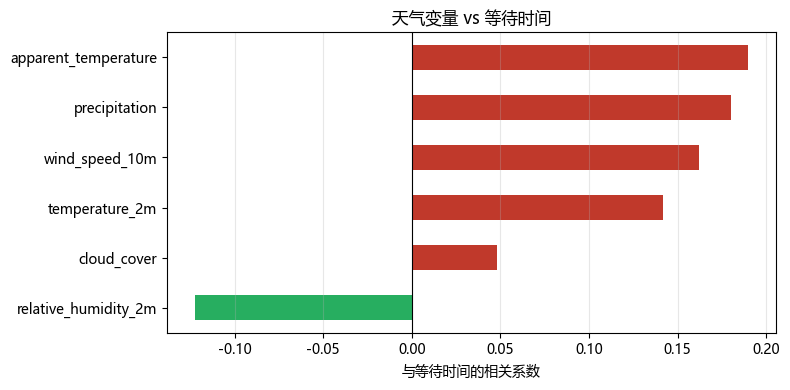

relative_humidity_2m   -0.123
cloud_cover             0.048
temperature_2m          0.142
wind_speed_10m          0.162
precipitation           0.180
apparent_temperature    0.190


In [6]:
corr = A.weather_correlations(df)
fig, ax = plt.subplots(figsize=(8, 4))
corr.plot(kind='barh', ax=ax, color=['#27ae60' if v<0 else '#c0392b' for v in corr])
ax.axvline(0, color='k', lw=0.8); ax.set_xlabel('与等待时间的相关系数'); ax.set_title('天气变量 vs 等待时间')
ax.grid(alpha=0.3, axis='x'); plt.tight_layout(); plt.show()
print(corr.round(3).to_string())

In [7]:
print('按天气分类的平均等待：'); print(A.by_weather_group(df).round(1).to_string(index=False))
rain = df.groupby(df['is_rain'].fillna(False))['wait_time'].mean()
print(f'\n雨天 {rain.get(True, float("nan")):.1f} 分 vs 非雨 {rain.get(False):.1f} 分')

按天气分类的平均等待：
weather_group  mean  median  count
           阵雨  60.0    60.0      2
            晴  64.0    70.0     34
           多云  65.4    65.0     28
            阴  65.4    60.0     26
          毛毛雨  79.5    80.0     39

雨天 78.5 分 vs 非雨 64.8 分


**读图**：所有天气变量与等待的相关性都**很弱**（|r| ≤ 0.21）。天气**不是有用的预测因子**，影响远小于**时段**。雨天平均反而略高，但幅度小、样本少，属噪声。

## 5. 结论

In [8]:
r = A.best_time_conclusion(df)
print('='*46)
print(f"清洗后样本 {r['n']} 条，整体平均 {r['overall_mean']} 分钟")
print('='*46)
print(f"一天中最短：{r['best_hour']}:00（约 {r['best_hour_mean']} 分）| 最长：{r['worst_hour']}:00（约 {r['worst_hour_mean']} 分）")
print(f"工作日 {r['wkday_mean']} 分 vs 周末 {r['wknd_mean']} 分（差异不显著）")
print(f"最空星期(参考,不可靠)：{r['best_dow']} | 最挤：{r['worst_dow']}")
print(f"雨天 {r['rain_mean']} vs 非雨 {r['dry_mean']} 分")

清洗后样本 129 条，整体平均 69.2 分钟
一天中最短：10:00（约 36.0 分）| 最长：13:00（约 89.0 分）
工作日 69.4 分 vs 周末 68.4 分（差异不显著）
最空星期(参考,不可靠)：周日 | 最挤：周一
雨天 78.5 vs 非雨 64.8 分


### 最终结论

**想少排队，最有效的一招是早去——一开园（10:00）就冲，避开 11:00–18:00 全天高位（13:00 前后最挤）。**

1. **几点去（清晰、稳健）**：开园 10:00 最短（约 35 分），是白天高峰（约 70–89 分）的**不到一半**。一进园就先刷这两台过山车最划算。19:00 前后也有回落，但样本少、不如开园可靠。
2. **星期几去（当前无法可靠回答）**：工作日与周末几乎持平（各约 68 分）。按天看周日 / 周二略低、周一略高，但**每个星期几只有约 1 天数据，属随机波动**，不能作为依据——需累积数周后再判断。就目前而言，**选哪天的影响远小于选几点**。
3. **天气（可忽略）**：相关性都很弱（|r|≤0.21），雨天也不更短，不必据天气安排行程。

> **本轮改进**：① 剔除 21 条 `wait_time==0` 的假零（停运/故障）避免误判低谷；② 天气改用 15 分钟粒度、就近抓取时刻对齐（差约 6 分钟，原整点差约 24 分钟）；③ 补充星期维度结论。
> **数据局限**：仅约 8 天、每星期几约 1 天，小时级规律较稳、星期与天气结论不可靠。重跑 `fetch_data.py` 后重新执行本 notebook 即可随数据累积更新。